In [ ]:
import gc
import itertools
import math
import os
import random
import sys
from collections import Counter, defaultdict
from copy import deepcopy
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias

import einops
import numpy as np
import pandas as pd
import torch as t
from datasets import load_dataset
from IPython.display import clear_output, display
from jaxtyping import Float, Int
from rich import print as rprint
from rich.table import Table

from transformer_lens import HookedTransformer, HookedTransformerConfig
from tabulate import tabulate
from torch import Tensor, nn
from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, loading_from_pretrained
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, to_numpy
from transformer_lens import utils

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.sparse import csr_array
from scipy.sparse.csgraph import maximum_bipartite_matching, min_weight_full_bipartite_matching

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")


## Model & State_dict Loading 

In [2]:
import importlib

# ------------------- Specify Model Arch -------------------
arch = "l8_h8"

# ------------------- Load Model Config -------------------

def load_named_config(module_name: str, config_name: str) -> dict:
    """
    Import a module that defines CONFIGS: Dict[str, Dict[str, Any]]
    and return CONFIGS[config_name].
    """
    try:
        mod = importlib.import_module(module_name)
    except Exception as e:
        raise ImportError(f"Could not import config module '{module_name}': {e}") from e

    if not hasattr(mod, "CONFIGS"):
        raise AttributeError(f"Module '{module_name}' does not define CONFIGS.")

    CONFIGS = getattr(mod, "CONFIGS")
    if config_name not in CONFIGS:
        available = ", ".join(sorted(CONFIGS.keys()))
        raise KeyError(f"Config '{config_name}' not found in {module_name}. Available: {available}")

    return dict(CONFIGS[config_name])  # copy so we can tweak

cfg_dict = load_named_config("model_configs", arch)


# ------------------- Model Configuration -------------------

# Build HookedTransformerConfig using the loaded config
cfg = HookedTransformerConfig(
    n_layers=cfg_dict["n_layers"],
    d_model=cfg_dict["d_model"],
    n_heads=cfg_dict["n_heads"],
    d_head=cfg_dict["d_head"],
    d_mlp=cfg_dict.get("d_mlp", None),
    n_ctx=cfg_dict["n_ctx"],
    act_fn=cfg_dict.get("act_fn", "gelu"),
    d_vocab=cfg_dict["d_vocab"],
    init_weights=True,
    tokenizer_name=cfg_dict["tokenizer_name"],
    model_name=cfg_dict.get("model_name", arch),
    attn_only=cfg_dict.get("attn_only", False),
)

## Prompt Sentences Data

In [3]:
import pickle

prompts_file = "100_prompts"

with open(f"./{prompts_file}.pkl", "rb") as f:
    prompts = pickle.load(f)

print(f"Loaded {len(prompts)} prompts from ./{prompts_file}.pkl")

Loaded 100 prompts from ./100_prompts.pkl


## Stability comparison: Adam vs AdamW

In [ ]:
 
# Setting device to CPU as GPU memory is insufficient for this computation, but for smaller number of prompts/models it can be set to GPU
device = 'cpu'

# Run for each arch but only for the single mentioned epoch (first entry of epoch_list).
# Then plot all arch curves on the same plot.
arch_list = [f"{arch}", f"{arch}_wd"]

# constants
SEEDS = [i for i in range(1,51)]
if "gpt2" in arch:
    SEEDS = [i for i in range(1,6)]
SCRATCH = "Path to root directory"
chkpt_file = "final.pt"
shard = 9
epoch = 1

# Constants
NUM_LAYERS = cfg.n_layers
NUM_HEADS = cfg.n_heads
ATTN_ONLY = cfg.attn_only

# Define function to extract lower triangular part of attention matrix
def lower_triang(mat):
    lower_triangular_mat = torch.tril(mat)
    mask = torch.tril(torch.ones_like(mat, device=device)).bool()
    lower_triangular_vec = lower_triangular_mat[mask]
    return lower_triangular_vec

# Initialize cosine similarity module
cos = t.nn.CosineSimilarity(dim=1, eps=1e-08)

# storage across architectures for combined plotting
arch_layer_means = {}
arch_layer_vars = {}

for arch in arch_list:
    print(f"Processing arch {arch} (epoch {epoch}) ...")

    # Models weights directory
    chkpt_dir = SCRATCH + "chkpts/" + arch
    print(f"chkpt_dir: {chkpt_dir}/{arch}")

    print(f"Processing arch: {arch}")
    cfg_dict = load_named_config("model_configs", arch)

    # Build HookedTransformerConfig for this arch
    cfg = HookedTransformerConfig(
        n_layers=cfg_dict["n_layers"],
        d_model=cfg_dict["d_model"],
        n_heads=cfg_dict["n_heads"],
        d_head=cfg_dict["d_head"],
        d_mlp=cfg_dict.get("d_mlp", None),
        n_ctx=cfg_dict["n_ctx"],
        act_fn=cfg_dict.get("act_fn", "gelu"),
        d_vocab=cfg_dict["d_vocab"],
        init_weights=True,
        tokenizer_name=cfg_dict["tokenizer_name"],
        model_name=cfg_dict.get("model_name", arch),
        attn_only=cfg_dict.get("attn_only", False),
    )

    # Load models for this epoch
    models = []
    for SEED in SEEDS:
        cfg.seed = SEED
        cfg.init_weights = True
        model = HookedTransformer(cfg)
        models.append(model)

    for ind, SEED in enumerate(SEEDS):
        if (arch == "gpt2") or (arch == "gpt2_wd"):
            model_state_dict = t.load(chkpt_dir + f"/gpt2_seed{SEED}_shard{shard}_epoch{epoch}_owt/{chkpt_file}")
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)
        else:
            if ATTN_ONLY:
                model_state_dict = t.load(
                    chkpt_dir + f"/causal_attn_only_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
                )
                models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

            else:
                model_state_dict = t.load(
                    chkpt_dir + f"/causal_attn_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
                )
                models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)


    # run prompts to collect caches (using CPU to avoid CUDA OOM)
    prompts_cache = []
    for prompt in prompts:
        cache_for_prompt = []
        for ind in range(len(SEEDS)):
            _, cache_i = models[ind].run_with_cache(prompt, remove_batch_dim=True)
            # Keep cache on CPU
            cache_i = cache_i.to('cpu')
            cache_for_prompt.append(cache_i)
        prompts_cache.append(cache_for_prompt)

    # Constants
    NUM_MODELS = len(models)
    NUM_HEADS = models[0].cfg.n_heads
    NUM_LAYERS = models[0].cfg.n_layers
    NUM_PROMPTS = len(prompts_cache)
    
    
    # Free memory held by models
    del models
    del model_state_dict
    torch.cuda.empty_cache()
    
    print("Computing cosine similarity matrix...")
    prompts_cs_matrix = t.empty(( NUM_LAYERS, NUM_HEADS, NUM_MODELS, NUM_HEADS, NUM_PROMPTS), device=device)

    # Setting Anchor seed/refit
    anchor = 0

    # Compute cosine-similarity matrix across layers/heads/models per prompt
    for ind_prompt in range(NUM_PROMPTS):
        cache = prompts_cache[ind_prompt]
        cache_anchor = cache[anchor].to(device)
        
        for layer in range(NUM_LAYERS):
            for head_anchor in range(NUM_HEADS):
                    
                    head_anchor_attn = cache_anchor[utils.get_act_name('pattern',layer,'a')][head_anchor]
                    head_anchor_attn = lower_triang(head_anchor_attn.to(device))
                    head_anchor_attn = t.unsqueeze(head_anchor_attn, 0)

                    for model_i in range(NUM_MODELS):
                        cache_model_i = cache[model_i].to(device)
                        for head_pair in range(NUM_HEADS):
                            head_i_attn = cache_model_i[utils.get_act_name('pattern',layer,'a')][head_pair]
                            head_i_attn = lower_triang(head_i_attn.to(device))
                            head_i_attn = t.unsqueeze(head_i_attn, 0)
                            cos_score_i = cos(head_anchor_attn, head_i_attn)
                            prompts_cs_matrix[layer, head_anchor, model_i, head_pair, ind_prompt] = cos_score_i
                            del head_i_attn, cos_score_i

                        del cache_model_i

                    del head_anchor_attn

        del cache_anchor
        torch.cuda.empty_cache()

    # Get best-matching head & Aggregate to get per-(layer, head_anchor)
    results = []
    for layer_i in range(NUM_LAYERS):
        csh = prompts_cs_matrix[layer_i,:,:,:]                # [head_anchor, model_i, head_pair, prompts]
        csh = torch.mean(csh, -1)                            # mean over prompts -> [head_anchor, model_i, head_pair]
        csh = csh.max(dim=-1, keepdim=True)                  # max over head_pair -> values shape [head_anchor, model_i, 1]
        csh = csh.values[:,:,0]                              # [head_anchor, model_i]
        csh = torch.cat([csh[:, :anchor], csh[:, anchor+1:]], dim=1) # remove comparison of anchor model with itself
        csh = csh.mean(dim=-1).reshape(NUM_HEADS, 1)         # mean over models -> [head_anchor, 1]

        # store results
        for head_anchor in range(NUM_HEADS):
            results.append({
                "layer": layer_i + 1,
                "head_anchor": head_anchor + 1,
                "cos_sim": csh[head_anchor].item()
            })

    df_layer_sim = pd.DataFrame(results)

    # collect per-layer mean & var
    layer_means = []
    layer_vars = []
    ticklabel_layers = [i for i in range(1, NUM_LAYERS+1)]
    for layer in ticklabel_layers:
        layer_df = df_layer_sim[df_layer_sim['layer'] == layer]
        layer_means.append(layer_df['cos_sim'].mean())
        layer_vars.append(layer_df['cos_sim'].var())

    arch_layer_means[arch] = layer_means
    arch_layer_vars[arch] = layer_vars



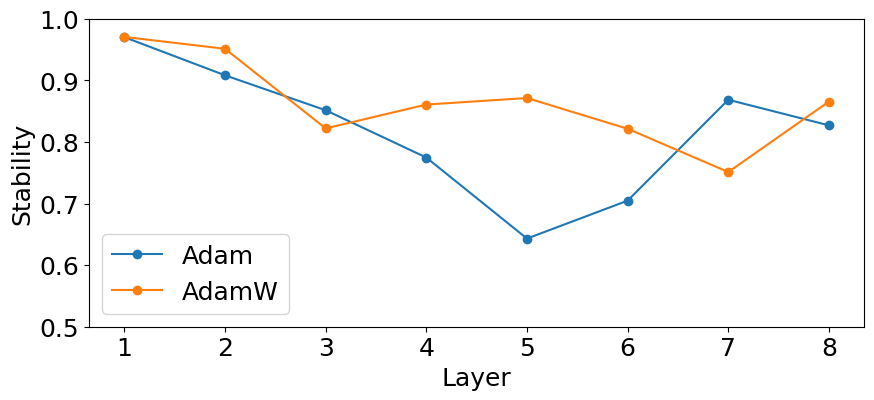

In [7]:
# Combined plots: all architectures on same axes for the selected epoch
plt.figure(figsize=(10,4))
for arch in arch_list:
    plt.plot(ticklabel_layers, arch_layer_means[arch], marker='o', label='Adam' if arch == arch_list[0] else 'AdamW')
plt.xlabel('Layer', fontsize=18)
plt.ylabel('Stability', fontsize=18)
#plt.title(f'Stability comparison for 8-layers 8-heads MLP architecture: Adam vs AdamW')
plt.ylim(0.5,1)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.show()


## Adam vs AdamW - Mechanistic check

In [ ]:
# Notebook cell: mean L2 norms of attn_out and resid_mid (with robust fallbacks)

import torch as t
import pandas as pd
from typing import List, Optional

def _pick_hook_template(model, candidates: List[str], layer0_prefix="blocks.0"):
    """
    Given candidate hook names for layer 0, return a template 'blocks.{l}.<hook>'
    for the first one found in cache.
    """
    test_tokens = model.to_tokens("test", prepend_bos=True)
    with t.no_grad():
        _, cache = model.run_with_cache(test_tokens, return_type=None)

    for name in candidates:
        if name in cache:
            del cache
            return name.replace(layer0_prefix, "blocks.{l}")

    del cache
    raise ValueError(
        "None of the candidate hooks were found. "
        "Inspect cache.keys() to see available hook names."
    )

def _pick_attn_out_template(model) -> str:
    # Stable order: true attn output -> attn result (if enabled) -> z (pre-W_O)
    candidates = [
        "blocks.0.hook_attn_out",      # most stable "attn_out"
        "blocks.0.attn.hook_result",   # only if cfg.use_attn_result=True
        "blocks.0.attn.hook_z",        # fallback (pre W_O)
    ]
    return _pick_hook_template(model, candidates)

def _pick_resid_after_attn_template(model) -> str:
    # Prefer resid_mid (between attn and mlp). If absent, use resid_post (after attn),
    # common in attn-only models. Last resort resid_pre.
    candidates = [
        "blocks.0.hook_resid_mid",
        "blocks.0.hook_resid_post",
        "blocks.0.hook_resid_pre",
    ]
    return _pick_hook_template(model, candidates)

def mean_l2_norms_attn_out_and_resid_mid(
    model,
    prompts: List[str],
    batch_size: int = 8,
    prepend_bos: bool = True,
    device: Optional[str] = None,
) -> pd.DataFrame:
    """
    Mean per-token L2 norms, averaged over tokens+prompts (padding excluded), for:
      - attn_out  : best available attn-out hook
      - resid_mid : best available residual-after-attn hook (resid_mid if present)

    Returns DataFrame with one row per layer.
    """
    model.eval()
    if device is None:
        device = "cuda" if t.cuda.is_available() else "cpu"
    model = model.to(device)

    tokenizer = model.tokenizer
    n_layers = model.cfg.n_layers

    attn_template  = _pick_attn_out_template(model)
    resid_template = _pick_resid_after_attn_template(model)

    attn_sums  = t.zeros(n_layers, dtype=t.float64)
    resid_sums = t.zeros(n_layers, dtype=t.float64)
    total_tokens = 0.0

    bos_id = getattr(tokenizer, "bos_token_id", None)

    # Build hook names for filtering once
    hook_names = []
    for l in range(n_layers):
        hook_names.append(attn_template.format(l=l))
        hook_names.append(resid_template.format(l=l))

    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]

        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            add_special_tokens=True,
        )
        tokens = enc["input_ids"]
        mask   = enc["attention_mask"]  # 1 real, 0 pad

        if prepend_bos and bos_id is not None:
            bos_col = t.full((tokens.size(0), 1), bos_id, dtype=t.long)
            tokens = t.cat([bos_col, tokens], dim=1)
            mask   = t.cat([t.ones((mask.size(0), 1), dtype=mask.dtype), mask], dim=1)

        tokens = tokens.to(device)
        mask   = mask.to(device).float()  # [batch, seq]

        with t.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                return_type=None,
                names_filter=hook_names,
            )

        batch_token_count = mask.sum().item()
        total_tokens += batch_token_count

        for l in range(n_layers):
            attn  = cache[attn_template.format(l=l)]     # [batch, seq, d_model] or [batch, seq, head, d_head]
            resid = cache[resid_template.format(l=l)]    # [batch, seq, d_model]

            # If attn hook is z/result with head dim, flatten last two dims
            if attn.ndim == 4:
                attn = attn.reshape(attn.shape[0], attn.shape[1], -1)

            attn_norm  = t.linalg.norm(attn, dim=-1)     # [batch, seq]
            resid_norm = t.linalg.norm(resid, dim=-1)    # [batch, seq]

            attn_sums[l]  += (attn_norm  * mask).sum().double().cpu()
            resid_sums[l] += (resid_norm * mask).sum().double().cpu()

        del cache

    attn_means  = attn_sums / total_tokens
    resid_means = resid_sums / total_tokens

    return pd.DataFrame({
        "layer": list(range(n_layers)),
        "attn_out_hook_used":  [attn_template] * n_layers,
        "resid_hook_used":     [resid_template] * n_layers,
        "attn_out_mean_l2":    attn_means.numpy(),
        "resid_mid_mean_l2":   resid_means.numpy(),
    })


# Run for each arch but only for the single mentioned epoch (first entry of epoch_list).
# Then plot all arch curves on the same plot.
arch = arch_list[0]
epoch_list = [1, 2]
arch_list = [f"{arch}", f"{arch}_wd"]

# pick only the mentioned epoch (first one). Change this if you want a different single epoch.
epoch_to_run = epoch_list[0]

ylim_max = 150

# Setting Anchor seed/refit
anchor = 1
SEEDS = [anchor]
SCRATCH = "Path to root directory"
shard_file = "final.pt"

# helper (kept from original)
def lower_triang(mat):
    lower_triangular_mat = torch.tril(mat)
    mask = torch.tril(torch.ones_like(mat, device=device)).bool()
    lower_triangular_vec = lower_triangular_mat[mask]
    return lower_triangular_vec

cos = t.nn.CosineSimilarity(dim=1, eps=1e-08)

# storage across architectures for combined plotting
arch_layer_means = {}
arch_layer_vars = {}

for arch in arch_list:
    print(f"Processing arch {arch} (epoch {epoch_to_run}) ...")

    # Load models for this epoch
    models = []
    for SEED in SEEDS:
        cfg.seed = SEED
        cfg.init_weights = True
        model = HookedTransformer(cfg)
        models.append(model)

    for ind, SEED in enumerate(SEEDS):
        model_state_dict = t.load(
            SCRATCH + f"chkpts/{arch}/causal_attn_l8_h8_seed{SEED}_epoch{epoch_to_run}_c4_gelu/{shard_file}"
        )
       
        models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

   
    model = models[0]
    df_norms = mean_l2_norms_attn_out_and_resid_mid(model, prompts, batch_size=4)

    # Plot attn_out_mean_l2 and resid_mid_mean_l2 for all layers
    plt.figure(figsize=(8,4))
    x = df_norms['layer'] + 1  # convert 0-based layer indices to 1-based for display
    plt.plot(x, df_norms['attn_out_mean_l2'], marker='o', label='attn_out_mean_l2')
    plt.plot(x, df_norms['resid_mid_mean_l2'], marker='o', label='resid_mid_mean_l2')
    plt.xticks(x)
    plt.xlabel('Layer')
    plt.ylabel('Mean L2 norm')
    plt.ylim(0, ylim_max)
    plt.legend()
    plt.show()




In [ ]:
# storage across architectures for combined plotting
arch_layer_means = {}
arch_layer_vars = {}

# prepare a single figure for all architectures
plt.figure(figsize=(10,5))

for arch in arch_list:
    print(f"Processing arch {arch} (epoch {epoch_to_run}) ...")

    # Load models for this epoch
    models = []
    for SEED in SEEDS:
        cfg.seed = SEED
        cfg.init_weights = True
        model = HookedTransformer(cfg)
        models.append(model)

    for ind, SEED in enumerate(SEEDS):
        model_state_dict = t.load(
            SCRATCH + f"chkpts/{arch}/causal_attn_l8_h8_seed{SEED}_epoch{epoch_to_run}_c4_gelu/{shard_file}"
        )
        models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

    model = models[0]
    df_norms = mean_l2_norms_attn_out_and_resid_mid(model, prompts, batch_size=4)

    
    x = df_norms['layer'] + 1  # convert 0-based layer indices to 1-based for display

    colors = ['#1f77b4', '#ff7f0e']  # matplotlib default blue and orange

    if "_wd" in arch:
        arch_label = "AdamW"
        plt.plot(x, df_norms['attn_out_mean_l2'], marker='o', color=colors[0], label=f'Attention output norm ({arch_label})')
        plt.plot(x, df_norms['resid_mid_mean_l2'], marker='s', color=colors[1], label=f'Residual stream norm ({arch_label})')
    else:
        arch_label = "Adam"
        plt.plot(x, df_norms['attn_out_mean_l2'], marker='o', linestyle='--', color=colors[0], label=f'Attention output norm ({arch_label})')
        plt.plot(x, df_norms['resid_mid_mean_l2'], marker='s', linestyle='--', color=colors[1], label=f'Residual stream norm ({arch_label})')
# finalize single combined plot
plt.xticks(x)
plt.xlabel('Layer', fontsize=18)
plt.ylabel('Mean L2 norm', fontsize=18)
#plt.title(f'Activations L2 norm: Attention output vs Residual stream, Architecture: L8 H8 MLP')
plt.ylim(0, ylim_max)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=12)
plt.show()
